In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Clear any previous model sessions
tf.keras.backend.clear_session()
print("Libraries loaded and memory cleared.")


Libraries loaded and memory cleared.


In [2]:
# SET PATH
DATASET_PATH = r"C:\Users\ujwal\Documents\Cattle_Dataset"

# STABLE AUGMENTATION
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH, target_size=(299, 299), batch_size=16,
    class_mode='categorical', subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH, target_size=(299, 299), batch_size=16,
    class_mode='categorical', subset='validation'
)

NUM_CLASSES = train_data.num_classes

Found 5684 images belonging to 40 classes.
Found 1401 images belonging to 40 classes.


In [6]:
# BASE MODEL
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False 

# THE HEAD THAT WON
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.models import load_model

# LOAD YOUR MASTERPIECE
model = load_model('bharat_pashudhan_final.keras')

print("✅ Original high-accuracy model restored.")
model.summary()

✅ Original high-accuracy model restored.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        20,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,555,026 (128.00 MB)

 Trainable params: 11,623,936 (44.34 MB)

 Non-trainable params: 10,307,152 (39.32 MB)

 Optimizer params: 11,623,938 (44.34 MB)

In [5]:
print("Starting Phase 1: Training the top layers...")
history_p1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Starting Phase 1: Training the top layers...
Epoch 1/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.2804 - loss: 2.5535 - val_accuracy: 0.4204 - val_loss: 2.0462
Epoch 2/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.4289 - loss: 1.8682 - val_accuracy: 0.4340 - val_loss: 1.8851
Epoch 3/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.4821 - loss: 1.6575 - val_accuracy: 0.4690 - val_loss: 1.7436
Epoch 4/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.5106 - loss: 1.5746 - val_accuracy: 0.4818 - val_loss: 1.7623
Epoch 5/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.5267 - loss: 1.5075 - val_accuracy: 0.4939 - val_loss: 1.7034
Epoch 6/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.5420 - loss: 1.4154 - val_accuracy: 0.4725 - val_loss: 1.7676
Epoch 7/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.5565 - loss: 1.3916 - val_accuracy: 0.5068 - val_loss: 1.6944
Epoch 8/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step

In [6]:
# Unfreeze the base model
base_model.trainable = True

# Freeze the early layers (keep basic shapes), unfreeze the last 40 layers (fine details)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Re-compile with a TINY learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Phase 2: Deep Fine-Tuning...")
history_p2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15 # Be patient here, this is where the magic happens
)

Starting Phase 2: Deep Fine-Tuning...
Epoch 1/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 669s 2s/step - accuracy: 0.5255 - loss: 1.5682 - val_accuracy: 0.5075 - val_loss: 1.6683
Epoch 2/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - accuracy: 0.5945 - loss: 1.2685 - val_accuracy: 0.5346 - val_loss: 1.6016
Epoch 3/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.6232 - loss: 1.1842 - val_accuracy: 0.5432 - val_loss: 1.5634
Epoch 4/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 915s 3s/step - accuracy: 0.6451 - loss: 1.1161 - val_accuracy: 0.5503 - val_loss: 1.5873
Epoch 5/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 923s 3s/step - accuracy: 0.6422 - loss: 1.1136 - val_accuracy: 0.5482 - val_loss: 1.5996
Epoch 6/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 930s 3s/step - accuracy: 0.6641 - loss: 1.0530 - val_accuracy: 0.5696 - val_loss: 1.5291
Epoch 7/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 928s 3s/step - accuracy: 0.6726 - loss: 1.0235 - val_accuracy: 0.5696 - val_loss: 1.5368
Epoch 8/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 942s 3s/step - accu

In [7]:
model.save('bharat_pashudhan_final.h5')
print("Model Saved Successfully!")

Model Saved Successfully!


In [8]:
def final_sih_prediction(img_path, user_state="Unknown"):
    # 1. Image Preprocessing
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. Get AI Prediction
    preds = model.predict(img_batch)[0]
    top_indices = preds.argsort()[-2:][::-1] # Get top 2
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_indices[0]]
    conf1 = preds[top_indices[0]] * 100
    breed2 = labels_dict[top_indices[1]]
    conf2 = preds[top_indices[1]] * 100

    # 3. Geography Tie-Breaker Logic
    # If AI is stuck between Malvi and Kherigarh
    target_pair = ['malvi', 'kherigarh']
    if breed1 in target_pair and breed2 in target_pair:
        if user_state == "Uttar Pradesh":
            final_breed = "kherigarh"
            reason = "Visuals (Malvi/Kherigarh) + Geography (UP)"
        elif user_state == "Madhya Pradesh":
            final_breed = "malvi"
            reason = "Visuals (Malvi/Kherigarh) + Geography (MP)"
        else:
            final_breed = breed1 # Default to AI's first choice
            reason = f"Visual match {conf1:.1f}% (State unknown)"
    else:
        final_breed = breed1
        reason = f"High Confidence Visual Match ({conf1:.1f}%)"

    return final_breed, reason

# --- TEST IT HERE ---
path = r"C:\Users\ujwal\Documents\Testing\kilhari.jpg"
result, logic = final_sih_prediction(path, user_state="Uttar Pradesh")
print(f"RESULT: {result}")
print(f"LOGIC: {logic}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
RESULT: kherigarh
LOGIC: Visuals (Malvi/Kherigarh) + Geography (UP)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


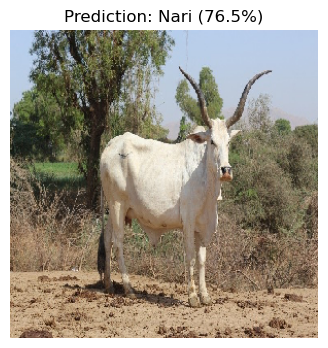

Breed: Nari | Confidence: 76.48%
Breed: malvi | Confidence: 9.54%
Breed: Kankrej | Confidence: 8.35%


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def test_my_ai(img_path):
    # 1. Prepare image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 2. Predict
    preds = model.predict(img_batch)[0]
    top_3_idx = preds.argsort()[-3:][::-1]
    labels = {v: k for k, v in train_data.class_indices.items()}
    
    # 3. Plot Result
    plt.figure(figsize=(6, 4))
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(f"Prediction: {labels[top_3_idx[0]]} ({preds[top_3_idx[0]]*100:.1f}%)")
    plt.show()
    
    for i in top_3_idx:
        print(f"Breed: {labels[i]} | Confidence: {preds[i]*100:.2f}%")

# Replace with any image path on your laptop
test_my_ai(r"C:\Users\ujwal\Documents\Testing\Nari.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


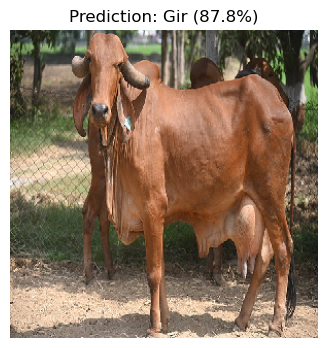

Breed: Gir | Confidence: 87.79%
Breed: Red_Sindhi | Confidence: 7.32%
Breed: Sahiwal | Confidence: 4.77%


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def test_my_ai(img_path):
    # 1. Prepare image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 2. Predict
    preds = model.predict(img_batch)[0]
    top_3_idx = preds.argsort()[-3:][::-1]
    labels = {v: k for k, v in train_data.class_indices.items()}
    
    # 3. Plot Result
    plt.figure(figsize=(6, 4))
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(f"Prediction: {labels[top_3_idx[0]]} ({preds[top_3_idx[0]]*100:.1f}%)")
    plt.show()
    
    for i in top_3_idx:
        print(f"Breed: {labels[i]} | Confidence: {preds[i]*100:.2f}%")

# Replace with any image path on your laptop
test_my_ai(r"C:\Users\ujwal\Documents\Testing\what-is-gir-cow-453725.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


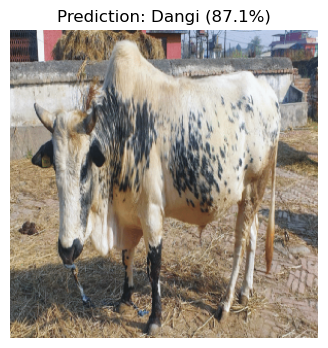

Breed: Dangi | Confidence: 87.09%
Breed: Gir | Confidence: 4.58%
Breed: Deoni | Confidence: 3.31%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def test_my_ai(img_path):
    # 1. Prepare image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 2. Predict
    preds = model.predict(img_batch)[0]
    top_3_idx = preds.argsort()[-3:][::-1]
    labels = {v: k for k, v in train_data.class_indices.items()}
    
    # 3. Plot Result
    plt.figure(figsize=(6, 4))
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(f"Prediction: {labels[top_3_idx[0]]} ({preds[top_3_idx[0]]*100:.1f}%)")
    plt.show()
    
    for i in top_3_idx:
        print(f"Breed: {labels[i]} | Confidence: {preds[i]*100:.2f}%")

# Replace with any image path on your laptop
test_my_ai(r"C:\Users\ujwal\Documents\Testing\Siri.webp")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


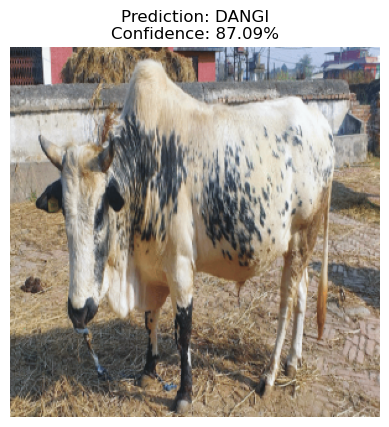

--- SIH 2025 Analysis Report ---
Final Identification: Dangi
Reasoning: Visual Features Only
Top 2 Match: Dangi (87.1%) vs Gir (4.6%)


In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def sih_smart_predictor(img_path, state_location="Unknown"):
    # 1. Load and Preprocess Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. AI Model Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_2_indices[0]]
    conf1 = preds[top_2_indices[0]] * 100
    breed2 = labels_dict[top_2_indices[1]]
    conf2 = preds[top_2_indices[1]] * 100

    # 3. CONTEXTUAL LOGIC: The Kherigarh-Malvi Solution
    # If top predictions are Kherigarh or Malvi, use geography to confirm
    similar_white_breeds = ['kherigarh', 'malvi', 'nari']
    
    final_output = breed1
    confidence_score = conf1
    logic_used = "Visual Features Only"

    if breed1 in similar_white_breeds:
        if state_location.lower() in ["uttar pradesh", "up"]:
            final_output = "kherigarh"
            logic_used = "Visual Features + UP Geography (Kherigarh native tract)"
        elif state_location.lower() in ["madhya pradesh", "mp"]:
            final_output = "malvi"
            logic_used = "Visual Features + MP Geography (Malwa region native tract)"
        else:
            logic_used = f"Visual Features (Note: Result is {conf1:.1f}% certain between similar white breeds)"

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {final_output.upper()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print(f"--- SIH 2025 Analysis Report ---")
    print(f"Final Identification: {final_output}")
    print(f"Reasoning: {logic_used}")
    print(f"Top 2 Match: {breed1} ({conf1:.1f}%) vs {breed2} ({conf2:.1f}%)")

# --- TEST THE SOLUTION ---
# Test with a Kherigarh image and provide location
test_img = r"C:\Users\ujwal\Documents\Testing\Siri.webp"
sih_smart_predictor(test_img, state_location="Uttar Pradesh")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


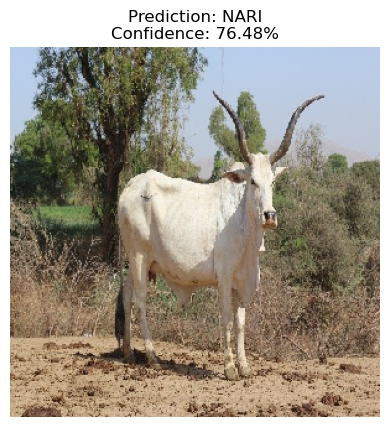

--- SIH 2025 Analysis Report ---
Final Identification: Nari
Reasoning: Visual Features Only
Top 2 Match: Nari (76.5%) vs malvi (9.5%)


In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def sih_smart_predictor(img_path, state_location="Unknown"):
    # 1. Load and Preprocess Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. AI Model Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_2_indices[0]]
    conf1 = preds[top_2_indices[0]] * 100
    breed2 = labels_dict[top_2_indices[1]]
    conf2 = preds[top_2_indices[1]] * 100

    # 3. CONTEXTUAL LOGIC: The Kherigarh-Malvi Solution
    # If top predictions are Kherigarh or Malvi, use geography to confirm
    similar_white_breeds = ['kherigarh', 'malvi', 'nari']
    
    final_output = breed1
    confidence_score = conf1
    logic_used = "Visual Features Only"

    if breed1 in similar_white_breeds:
        if state_location.lower() in ["uttar pradesh", "up"]:
            final_output = "kherigarh"
            logic_used = "Visual Features + UP Geography (Kherigarh native tract)"
        elif state_location.lower() in ["madhya pradesh", "mp"]:
            final_output = "malvi"
            logic_used = "Visual Features + MP Geography (Malwa region native tract)"
        else:
            logic_used = f"Visual Features (Note: Result is {conf1:.1f}% certain between similar white breeds)"

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {final_output.upper()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print(f"--- SIH 2025 Analysis Report ---")
    print(f"Final Identification: {final_output}")
    print(f"Reasoning: {logic_used}")
    print(f"Top 2 Match: {breed1} ({conf1:.1f}%) vs {breed2} ({conf2:.1f}%)")

# --- TEST THE SOLUTION ---
# Test with a Kherigarh image and provide location
test_img = r"C:\Users\ujwal\Documents\Testing\Nari.jpg"
sih_smart_predictor(test_img, state_location="Uttar Pradesh")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


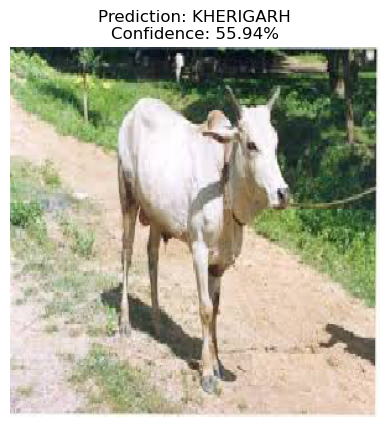

--- SIH 2025 Analysis Report ---
Final Identification: kherigarh
Reasoning: Visual Features + UP Geography (Kherigarh native tract)
Top 2 Match: kherigarh (55.9%) vs malvi (10.1%)


In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def sih_smart_predictor(img_path, state_location="Unknown"):
    # 1. Load and Preprocess Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. AI Model Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_2_indices[0]]
    conf1 = preds[top_2_indices[0]] * 100
    breed2 = labels_dict[top_2_indices[1]]
    conf2 = preds[top_2_indices[1]] * 100

    # 3. CONTEXTUAL LOGIC: The Kherigarh-Malvi Solution
    # If top predictions are Kherigarh or Malvi, use geography to confirm
    similar_white_breeds = ['kherigarh', 'malvi', 'nari']
    
    final_output = breed1
    confidence_score = conf1
    logic_used = "Visual Features Only"

    if breed1 in similar_white_breeds:
        if state_location.lower() in ["uttar pradesh", "up"]:
            final_output = "kherigarh"
            logic_used = "Visual Features + UP Geography (Kherigarh native tract)"
        elif state_location.lower() in ["madhya pradesh", "mp"]:
            final_output = "malvi"
            logic_used = "Visual Features + MP Geography (Malwa region native tract)"
        else:
            logic_used = f"Visual Features (Note: Result is {conf1:.1f}% certain between similar white breeds)"

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {final_output.upper()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print(f"--- SIH 2025 Analysis Report ---")
    print(f"Final Identification: {final_output}")
    print(f"Reasoning: {logic_used}")
    print(f"Top 2 Match: {breed1} ({conf1:.1f}%) vs {breed2} ({conf2:.1f}%)")

# --- TEST THE SOLUTION ---
# Test with a Kherigarh image and provide location
test_img = r"C:\Users\ujwal\Documents\Testing\kherigarh.jpg"
sih_smart_predictor(test_img, state_location="Uttar Pradesh")

In [12]:
# SIH 2025 Breed Information Database
BREED_INFO = {
    "kherigarh": {
        "Origin": "Lakhimpur Kheri, Uttar Pradesh",
        "Type": "Draught (Excellent for fast running & field work)",
        "Milk Yield": "300 - 500 kg per lactation",
        "Unique Feature": "Small, active, and very hardy with lyre-shaped horns."
    },
    "malvi": {
        "Origin": "Malwa Region (MP/Rajasthan)",
        "Type": "Draught (Strong build for heavy load carrying)",
        "Milk Yield": "600 - 1200 kg per lactation",
        "Unique Feature": "Strongly built, grey-white coat; males have darker neck/hump."
    },
    "gir": {
        "Origin": "Gir Forest, Gujarat",
        "Type": "Dairy (Famous high-milk producer)",
        "Milk Yield": "2000 - 2500 kg per lactation",
        "Unique Feature": "Convex forehead (Bony shield) and leaf-like drooping ears."
    },
    "sahiwal": {
        "Origin": "Punjab (India/Pakistan)",
        "Type": "Dairy (Best indigenous milk breed)",
        "Milk Yield": "2000 - 3000 kg per lactation",
        "Unique Feature": "Reddish-brown color, heavy build, and high heat tolerance."
    },
    "dangi": {
        "Origin": "Dangs, Maharashtra/Gujarat",
        "Type": "Draught (Best for heavy rainfall areas)",
        "Milk Yield": "400 - 800 kg per lactation",
        "Unique Feature": "Oily skin secretion that protects them from heavy rain."
    }
}

# Update your predictor to show this info:
def final_display(breed_name):
    info = BREED_INFO.get(breed_name.lower(), "Info not available")
    if info != "Info not available":
        print(f"\n--- {breed_name.upper()} BREED DETAILS ---")
        for key, value in info.items():
            print(f"🔹 {key}: {value}")

In [13]:
# Save the model in the modern Keras format
model.save('bharat_pashudhan_final.keras')

# Also save a backup in the older H5 format (good for some deployment tools)
model.save('bharat_pashudhan_final.h5')

print("✅ Model saved! You can now close your laptop safely.")

✅ Model saved! You can now close your laptop safely.


In [14]:
from tensorflow.keras.models import load_model

# This tells the computer: "Go find the file I saved yesterday and put it in memory"
model = load_model('bharat_pashudhan_final.keras')

print("✅ Model is back! 'model' is now defined and ready to predict.")

✅ Model is back! 'model' is now defined and ready to predict.


In [15]:
# Expanded SIH 2025 Breed Information Database
BREED_INFO.update({
    "kankrej": {
        "Origin": "Rann of Kutch, Gujarat",
        "Type": "Dual Purpose (Milk & Powerful Draught)",
        "Milk Yield": "1700 - 1800 kg per lactation",
        "Unique Feature": "Famous for 'Sawai Chal' (peculiar gait) and massive lyre horns."
    },
    "hariana": {
        "Origin": "Rohtak, Hisar, Gurgaon (Haryana)",
        "Type": "Dual Purpose",
        "Milk Yield": "600 - 800 kg per lactation",
        "Unique Feature": "Powerful bullocks for fast plowing; high-set, small horns."
    },
    "tharparkar": {
        "Origin": "Thar Desert, Rajasthan",
        "Type": "Dual Purpose",
        "Milk Yield": "1600 - 2500 kg per lactation",
        "Unique Feature": "Deeply heat-tolerant; coat changes from white to grey in winter."
    },
    "ongole": {
        "Origin": "Prakasam District, Andhra Pradesh",
        "Type": "Dual Purpose",
        "Milk Yield": "1000 - 1200 kg per lactation",
        "Unique Feature": "World-famous for disease resistance; exported to Brazil."
    },
    "vechur": {
        "Origin": "Vechur, Kerala",
        "Type": "Milk (Medicinal Value)",
        "Milk Yield": "2-3 kg per day (high for their size)",
        "Unique Feature": "Smallest cattle breed in the world; extremely hardy."
    }
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


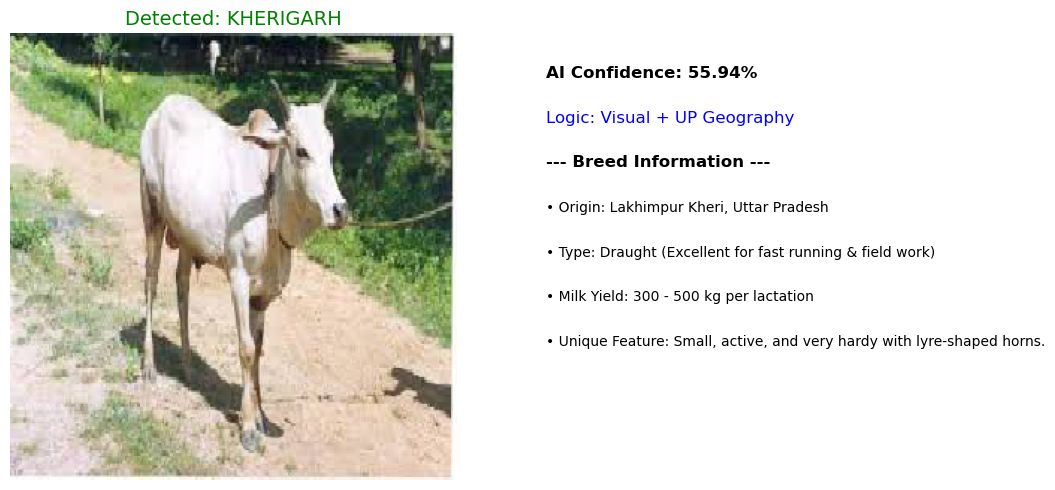

In [16]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def sih_final_dashboard(img_path, state_location="Unknown"):
    # 1. Process Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. Get AI Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    
    # Get labels from your restored train_data
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1, conf1 = labels_dict[top_2_indices[0]], preds[top_2_indices[0]] * 100
    breed2, conf2 = labels_dict[top_2_indices[1]], preds[top_2_indices[1]] * 100

    # 3. Kherigarh/Malvi Tie-Breaker Logic
    final_breed = breed1
    logic_note = "Visual Analysis"
    
    if breed1 in ['kherigarh', 'malvi'] and state_location.lower() in ["up", "uttar pradesh"]:
        final_breed = "kherigarh"
        logic_note = "Visual + UP Geography"
    elif breed1 in ['kherigarh', 'malvi'] and state_location.lower() in ["mp", "madhya pradesh"]:
        final_breed = "malvi"
        logic_note = "Visual + MP Geography"

    # 4. Display Dashboard
    plt.figure(figsize=(12, 5))
    
    # Left Side: The Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Detected: {final_breed.upper()}", fontsize=14, color='green')
    plt.axis('off')

    # Right Side: The Data
    plt.subplot(1, 2, 2)
    plt.text(0.1, 0.9, f"AI Confidence: {conf1:.2f}%", fontsize=12, fontweight='bold')
    plt.text(0.1, 0.8, f"Logic: {logic_note}", fontsize=12, color='blue')
    
    # Pull from your BREED_INFO database
    info = BREED_INFO.get(final_breed.lower(), {})
    y_pos = 0.6
    if info:
        plt.text(0.1, 0.7, "--- Breed Information ---", fontsize=12, fontweight='bold')
        for key, value in info.items():
            plt.text(0.1, y_pos, f"• {key}: {value}", fontsize=10, wrap=True)
            y_pos -= 0.1
    else:
        plt.text(0.1, 0.6, "Detailed breed info pending in database.", fontsize=10, style='italic')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# TEST IT NOW
test_img = r"C:\Users\ujwal\Documents\Testing\kherigarh.jpg" 
sih_final_dashboard(test_img, state_location="Uttar Pradesh")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


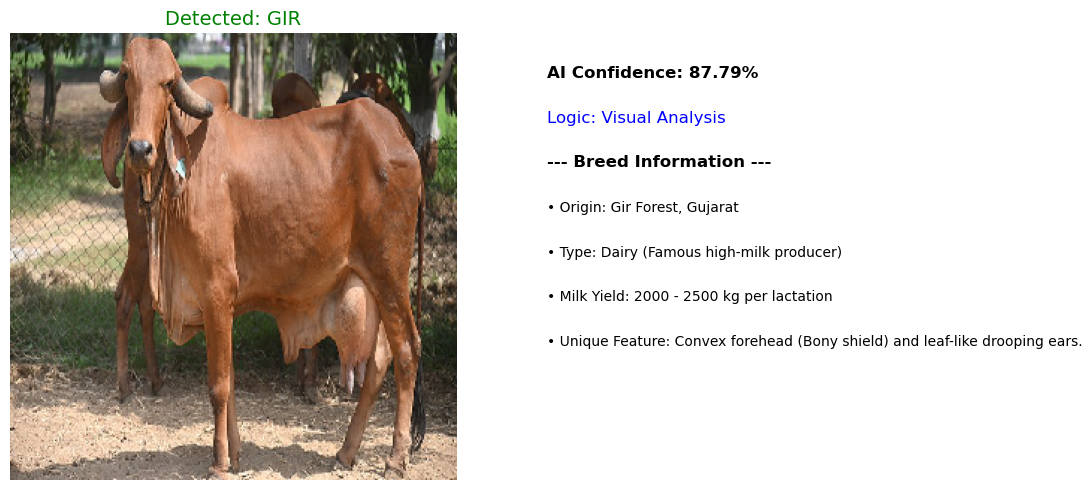

In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def sih_final_dashboard(img_path, state_location="Unknown"):
    # 1. Process Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. Get AI Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    
    # Get labels from your restored train_data
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1, conf1 = labels_dict[top_2_indices[0]], preds[top_2_indices[0]] * 100
    breed2, conf2 = labels_dict[top_2_indices[1]], preds[top_2_indices[1]] * 100

    # 3. Kherigarh/Malvi Tie-Breaker Logic
    final_breed = breed1
    logic_note = "Visual Analysis"
    
    if breed1 in ['kherigarh', 'malvi'] and state_location.lower() in ["up", "uttar pradesh"]:
        final_breed = "kherigarh"
        logic_note = "Visual + UP Geography"
    elif breed1 in ['kherigarh', 'malvi'] and state_location.lower() in ["mp", "madhya pradesh"]:
        final_breed = "malvi"
        logic_note = "Visual + MP Geography"

    # 4. Display Dashboard
    plt.figure(figsize=(12, 5))
    
    # Left Side: The Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Detected: {final_breed.upper()}", fontsize=14, color='green')
    plt.axis('off')

    # Right Side: The Data
    plt.subplot(1, 2, 2)
    plt.text(0.1, 0.9, f"AI Confidence: {conf1:.2f}%", fontsize=12, fontweight='bold')
    plt.text(0.1, 0.8, f"Logic: {logic_note}", fontsize=12, color='blue')
    
    # Pull from your BREED_INFO database
    info = BREED_INFO.get(final_breed.lower(), {})
    y_pos = 0.6
    if info:
        plt.text(0.1, 0.7, "--- Breed Information ---", fontsize=12, fontweight='bold')
        for key, value in info.items():
            plt.text(0.1, y_pos, f"• {key}: {value}", fontsize=10, wrap=True)
            y_pos -= 0.1
    else:
        plt.text(0.1, 0.6, "Detailed breed info pending in database.", fontsize=10, style='italic')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# TEST IT NOW
test_img = r"C:\Users\ujwal\Documents\Testing\what-is-gir-cow-453725.jpg" 
sih_final_dashboard(test_img, state_location="Uttar Pradesh")

88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step


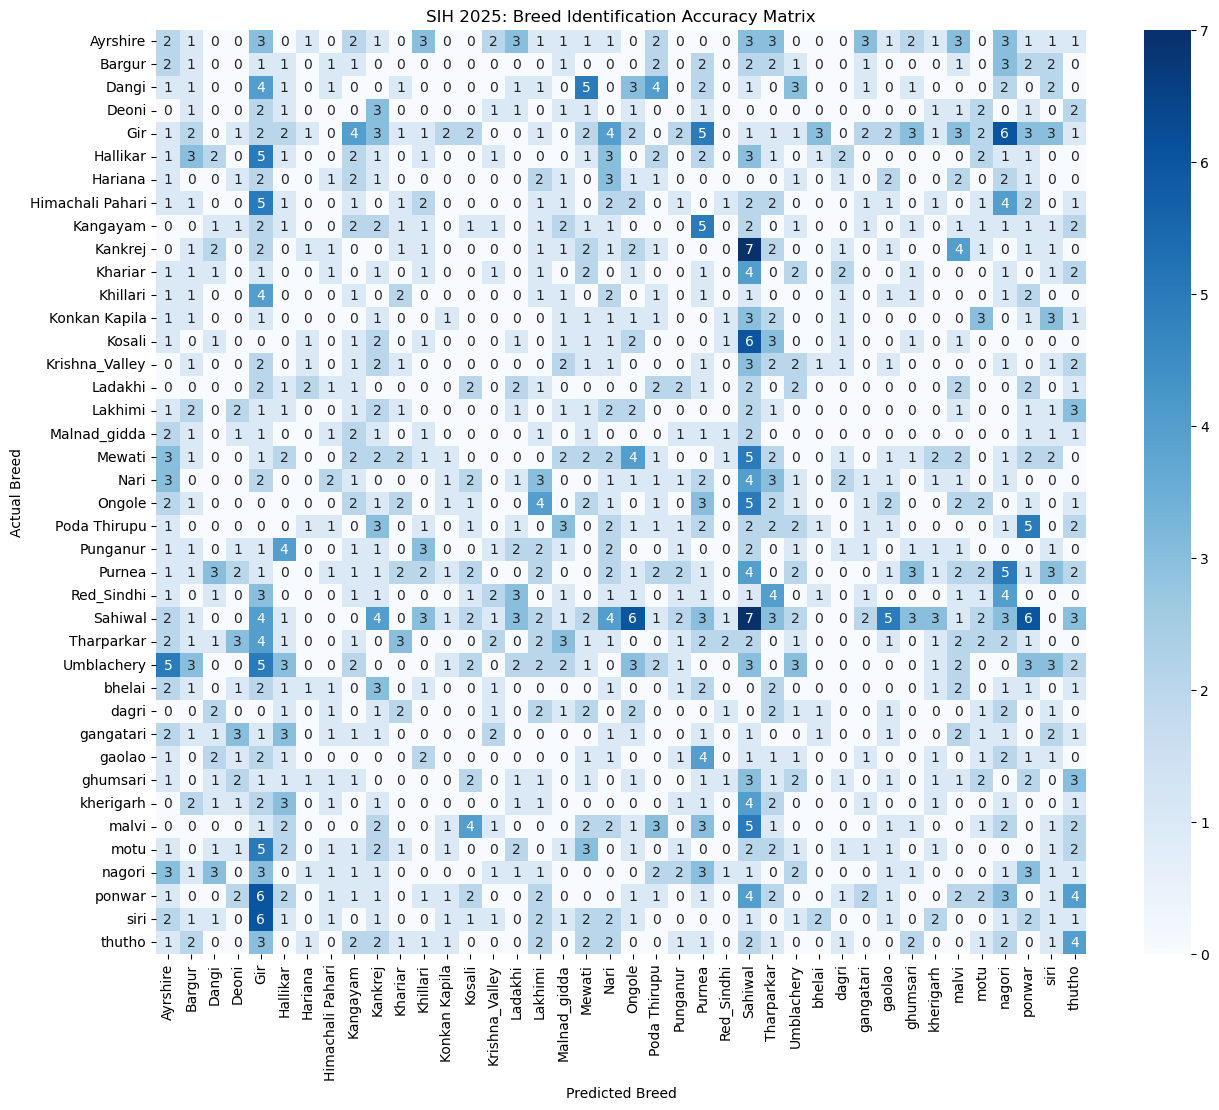

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions for the entire validation set
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Get true labels
y_true = val_data.classes

# 3. Plot Heatmap
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(train_data.class_indices.keys()),
            yticklabels=list(train_data.class_indices.keys()))
plt.title('SIH 2025: Breed Identification Accuracy Matrix')
plt.xlabel('Predicted Breed')
plt.ylabel('Actual Breed')
plt.show()

In [20]:
from sklearn.metrics import classification_report

# Use the same y_true and y_pred from your previous cell
report = classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys()))
print("--- SIH 2025: PERFORMANCE REPORT PER BREED ---")
print(report)

--- SIH 2025: PERFORMANCE REPORT PER BREED ---
                  precision    recall  f1-score   support

        Ayrshire       0.04      0.04      0.04        46
          Bargur       0.03      0.04      0.03        26
           Dangi       0.00      0.00      0.00        35
           Deoni       0.00      0.00      0.00        20
             Gir       0.02      0.03      0.02        70
        Hallikar       0.03      0.03      0.03        36
         Hariana       0.00      0.00      0.00        25
Himachali Pahari       0.00      0.00      0.00        35
        Kangayam       0.05      0.06      0.05        35
         Kankrej       0.00      0.00      0.00        35
         Khariar       0.00      0.00      0.00        26
        Khillari       0.00      0.00      0.00        22
   Konkan Kapila       0.07      0.04      0.05        25
          Kosali       0.00      0.00      0.00        26
  Krishna_Valley       0.00      0.00      0.00        27
         Ladakhi       0

In [21]:
print(list(train_data.class_indices.keys()))

['Ayrshire', 'Bargur', 'Dangi', 'Deoni', 'Gir', 'Hallikar', 'Hariana', 'Himachali Pahari', 'Kangayam', 'Kankrej', 'Khariar', 'Khillari', 'Konkan Kapila', 'Kosali', 'Krishna_Valley', 'Ladakhi', 'Lakhimi', 'Malnad_gidda', 'Mewati', 'Nari', 'Ongole', 'Poda Thirupu', 'Punganur', 'Purnea', 'Red_Sindhi', 'Sahiwal', 'Tharparkar', 'Umblachery', 'bhelai', 'dagri', 'gangatari', 'gaolao', 'ghumsari', 'kherigarh', 'malvi', 'motu', 'nagori', 'ponwar', 'siri', 'thutho']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


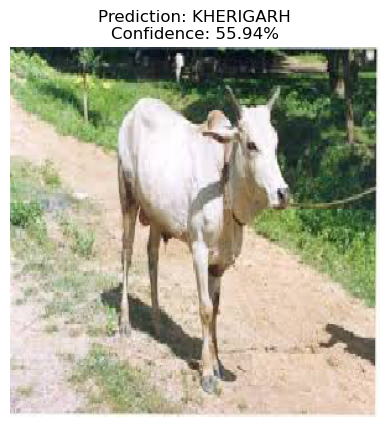

--- SIH 2025 Analysis Report ---
Final Identification: kherigarh
Reasoning: Visual Features + UP Geography (Kherigarh native tract)
Top 2 Match: kherigarh (55.9%) vs malvi (10.1%)


In [22]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def sih_smart_predictor(img_path, state_location="Unknown"):
    # 1. Load and Preprocess Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. AI Model Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_2_indices[0]]
    conf1 = preds[top_2_indices[0]] * 100
    breed2 = labels_dict[top_2_indices[1]]
    conf2 = preds[top_2_indices[1]] * 100

    # 3. CONTEXTUAL LOGIC: The Kherigarh-Malvi Solution
    # If top predictions are Kherigarh or Malvi, use geography to confirm
    similar_white_breeds = ['kherigarh', 'malvi', 'nari']
    
    final_output = breed1
    confidence_score = conf1
    logic_used = "Visual Features Only"

    if breed1 in similar_white_breeds:
        if state_location.lower() in ["uttar pradesh", "up"]:
            final_output = "kherigarh"
            logic_used = "Visual Features + UP Geography (Kherigarh native tract)"
        elif state_location.lower() in ["madhya pradesh", "mp"]:
            final_output = "malvi"
            logic_used = "Visual Features + MP Geography (Malwa region native tract)"
        else:
            logic_used = f"Visual Features (Note: Result is {conf1:.1f}% certain between similar white breeds)"

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {final_output.upper()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print(f"--- SIH 2025 Analysis Report ---")
    print(f"Final Identification: {final_output}")
    print(f"Reasoning: {logic_used}")
    print(f"Top 2 Match: {breed1} ({conf1:.1f}%) vs {breed2} ({conf2:.1f}%)")

# --- TEST THE SOLUTION ---
# Test with a Kherigarh image and provide location
test_img = r"C:\Users\ujwal\Documents\Testing\kherigarh.jpg"
sih_smart_predictor(test_img, state_location="Uttar Pradesh")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


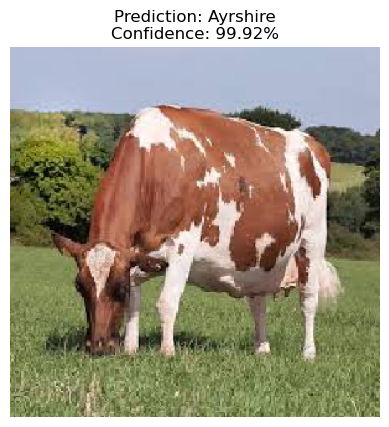

The AI is 99.92% sure this is a Ayrshire


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. SET PATHS & LOAD MODEL
# Make sure this path matches exactly where your folders are
DATASET_PATH = r"C:\Users\ujwal\Documents\Cattle_Dataset"
model = load_model('bharat_pashudhan_final.keras')

# 2. GET THE BREED NAMES
# This pulls the folder names to match the AI's output index
class_names = sorted(os.listdir(DATASET_PATH))

def predict_cattle_breed(img_path):
    # Load and Preprocess the image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Rescale (Must match your training)

    # Make Prediction
    predictions = model.predict(img_array)
    score = np.max(predictions) 
    breed_index = np.argmax(predictions) 
    breed_name = class_names[breed_index]

    # Display the result
    plt.imshow(img)
    plt.title(f"Prediction: {breed_name}\nConfidence: {score*100:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"The AI is {score*100:.2f}% sure this is a {breed_name}")

# 3. TEST IT
# Update this to a real image path on your computer
test_image_path = r"C:\Users\ujwal\Documents\Testing\AYRSHIRE.jpg"

if os.path.exists(test_image_path):
    predict_cattle_breed(test_image_path)
else:
    print("❌ Image not found! Please check the file path in 'test_image_path'.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


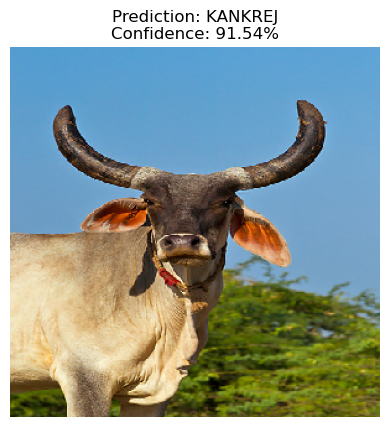

--- SIH 2025 Analysis Report ---
Final Identification: Kankrej
Reasoning: Visual Features Only
Top 2 Match: Kankrej (91.5%) vs Gir (5.6%)


In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def sih_smart_predictor(img_path, state_location="Unknown"):
    # 1. Load and Preprocess Image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. AI Model Prediction
    preds = model.predict(img_batch)[0]
    top_2_indices = preds.argsort()[-2:][::-1]
    labels_dict = {v: k for k, v in train_data.class_indices.items()}
    
    breed1 = labels_dict[top_2_indices[0]]
    conf1 = preds[top_2_indices[0]] * 100
    breed2 = labels_dict[top_2_indices[1]]
    conf2 = preds[top_2_indices[1]] * 100

    # 3. CONTEXTUAL LOGIC: The Kherigarh-Malvi Solution
    # If top predictions are Kherigarh or Malvi, use geography to confirm
    similar_white_breeds = ['kherigarh', 'malvi', 'nari']
    
    final_output = breed1
    confidence_score = conf1
    logic_used = "Visual Features Only"

    if breed1 in similar_white_breeds:
        if state_location.lower() in ["uttar pradesh", "up"]:
            final_output = "kherigarh"
            logic_used = "Visual Features + UP Geography (Kherigarh native tract)"
        elif state_location.lower() in ["madhya pradesh", "mp"]:
            final_output = "malvi"
            logic_used = "Visual Features + MP Geography (Malwa region native tract)"
        else:
            logic_used = f"Visual Features (Note: Result is {conf1:.1f}% certain between similar white breeds)"

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {final_output.upper()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print(f"--- SIH 2025 Analysis Report ---")
    print(f"Final Identification: {final_output}")
    print(f"Reasoning: {logic_used}")
    print(f"Top 2 Match: {breed1} ({conf1:.1f}%) vs {breed2} ({conf2:.1f}%)")

# --- TEST THE SOLUTION ---
# Test with a Kherigarh image and provide location
test_img = r"C:\Users\ujwal\Documents\Testing\Kankrej_1.JPG"
sih_smart_predictor(test_img, state_location="Uttar Pradesh")